# 機械学習実践プロジェクト_製造設備データを用いた機械故障予測モデルの構築

## データセットについて
このデータセット（Synthetic Dataset）は、実在する**フライス盤（Milling Machine）**をモデルとして作成されたもので、**10,000件のデータポイント**が行として格納され、**14個の特徴量（Features）**が列として構成されています。

### データ項目

1. **UID**
   1から10,000までの一意の識別子（Unique Identifier）。

2. **Product ID**
   製品品質のバリエーションを表す `L`、`M`、`H` のいずれかの文字と、各バリエーション固有のシリアル番号から構成されます。

   * `L`：Low（低品質）― 全製品の50%
   * `M`：Medium（中品質）― 全製品の30%
   * `H`：High（高品質）― 全製品の20%

3. **Type**
   Product IDの製品タイプを表し、`L`、`M`、`H` のいずれかです。

4. **Air Temperature [K]（気温）**
   ランダムウォーク（Random Walk）によって生成され、その後、**300 Kを中心として標準偏差2 K**になるように正規化されています。

5. **Process Temperature [K]（プロセス温度）**
   ランダムウォークによって生成され、標準偏差が**1 K**になるように正規化されています。その後、気温に約**10 K**を加えた値として設定されています。

6. **Rotational Speed [rpm]（回転速度）**
   **2,860 Wの出力**を基準として計算され、そこに正規分布に従うノイズが加えられています。

7. **Torque [Nm]（トルク）**
   トルク値は、平均**40 Nm**、標準偏差**10 Nm**の正規分布に従って生成されており、負の値は含まれません。

8. **Tool Wear [min]（工具摩耗時間）**
   製品品質のバリエーションによって、使用中の工具に以下の摩耗時間が追加されます。

   * `H`：5分
   * `M`：3分
   * `L`：2分

9. **Machine Failure（機械故障）**
   以下のいずれかの故障モードが発生した場合、そのデータポイントにおいて機械が故障したことを示すラベルです。

---

## 機械故障の5つの故障モード

機械故障は、以下の**5つの独立した故障モード**から構成されています。

### 1. Tool Wear Failure（TWF：工具摩耗故障）

工具は、**200～240分の間でランダムに選択された工具摩耗時間**に到達すると、交換または故障します。

この条件に該当するデータは、データセット内に**120件**あります。

その時点で、

* 69件：工具交換
* 51件：工具故障

としてランダムに割り当てられています。

### 2. Heat Dissipation Failure（HDF：放熱故障）

以下の2つの条件を同時に満たした場合、放熱不足によるプロセス故障が発生します。

* 気温とプロセス温度の差が **8.6 K未満**
* 工具の回転速度が **1,380 rpm未満**

この条件に該当するデータポイントは、**115件**です。

### 3. Power Failure（PWF：動力故障）

トルクと回転速度（rad/s）の積によって、プロセスに必要な動力（Power）が計算されます。

この動力が、

* **3,500 W未満**
* または **9,000 W超**

の場合、プロセス故障が発生します。

この条件に該当するデータポイントは、**95件**です。

### 4. Overstrain Failure（OSF：過負荷故障）

工具摩耗時間とトルクの積が、製品タイプごとに設定された以下のしきい値を超える場合、過負荷による故障が発生します。

* `L`：11,000 minNm
* `M`：12,000 minNm
* `H`：13,000 minNm

この条件に該当するデータポイントは、**98件**です。

### 5. Random Failures（RNF：ランダム故障）

各プロセスは、プロセスパラメータとは無関係に、**0.1%の確率**でランダムに故障します。

この条件による故障は、10,000件のデータポイントのうち**5件のみ**発生しています。これは、10,000件に対して理論的に期待される件数よりも少ない値です。

---

## Machine Failureラベル

上記5種類の故障モードのうち、**少なくとも1つがTrueになった場合、そのプロセスは故障したとみなされ、`Machine Failure` ラベルが `1` に設定されます。**

そのため、機械学習モデルから見た場合、`Machine Failure = 1` という情報だけでは、**具体的にどの故障モードが原因で機械故障が発生したのかは明示されません。**

---

### データの読み込み

In [84]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings("ignore")  # Ignore all warnings

In [85]:
df=pd.read_csv("ai4i2020.csv")
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


### 機械故障が発生したデータの確認

In [86]:
df[df["Machine failure"]==1]  # Machine failure が1（故障）のデータのみを抽出

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,1,0,0,0,0
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,0,0,0,1,0
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9758,9759,L56938,L,298.6,309.8,2271,16.2,218,1,1,0,0,0,0
9764,9765,L56944,L,298.5,309.5,1294,66.7,12,1,0,0,1,0,0
9822,9823,L57002,L,298.5,309.4,1360,60.9,187,1,0,0,0,1,0
9830,9831,L57010,L,298.3,309.3,1337,56.1,206,1,0,0,0,1,0


### データ前処理

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [88]:
df.isnull().sum()  # 各列に欠損値が存在するかを確認

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [89]:
df.duplicated().sum()  # データ内の重複行の件数を確認

np.int64(0)

In [90]:
# Understanding data types and unique values per column

In [91]:
df.dtypes  # 各列のデータ型を確認

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [92]:
df.nunique()  # 各列に含まれるユニークな値の数を確認

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [93]:
df['Type'].value_counts()  # Typeごとのデータ件数を確認

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [94]:
df.drop(columns=['UDI','Product ID'],inplace=True)  # 分析に不要な識別用の列（UDI、Product ID）を削除

### 特徴量エンジニアリング

In [95]:
# Creating new feature: temperature difference between process and air
# プロセス温度と空気温度の差を新しい特徴量として作成
df['temperature_difference']=df['Process temperature [K]']-df['Air temperature [K]']

In [96]:
# Creating new feature: mechanical power using torque and rotational speed
# トルクと回転速度から機械出力（Mechanical Power）を算出
df['Mechanical Power [W]']=np.round((df['Torque [Nm]']*df['Rotational speed [rpm]']* 2 * np.pi) / 60,4)

In [97]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_difference,Mechanical Power [W]
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.5906
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.7227
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.3875
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.5047
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.8166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,4955.1294
9996,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,5434.7040
9997,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,5753.6175
9998,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,7151.1026


### 記述統計量の確認

In [98]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.004930,2.000259,295.3000,298.3000,300.10000,301.5000,304.500
Process temperature [K],10000.0,310.005560,1.483734,305.7000,308.8000,310.10000,311.1000,313.800
Rotational speed [rpm],10000.0,1538.776100,179.284096,1168.0000,1423.0000,1503.00000,1612.0000,2886.000
Torque [Nm],10000.0,39.986910,9.968934,3.8000,33.2000,40.10000,46.8000,76.600
Tool wear [min],10000.0,107.951000,63.654147,0.0000,53.0000,108.00000,162.0000,253.000
Machine failure,10000.0,0.033900,0.180981,0.0000,0.0000,0.00000,0.0000,1.000
TWF,10000.0,0.004600,0.067671,0.0000,0.0000,0.00000,0.0000,1.000
HDF,10000.0,0.011500,0.106625,0.0000,0.0000,0.00000,0.0000,1.000
PWF,10000.0,0.009500,0.097009,0.0000,0.0000,0.00000,0.0000,1.000
OSF,10000.0,0.009800,0.098514,0.0000,0.0000,0.00000,0.0000,1.000


### 探索的データ分析

# 1) 機械タイプの分布を可視化

#### 各タイプ（L、M、H）に属する機械の台数を確認する

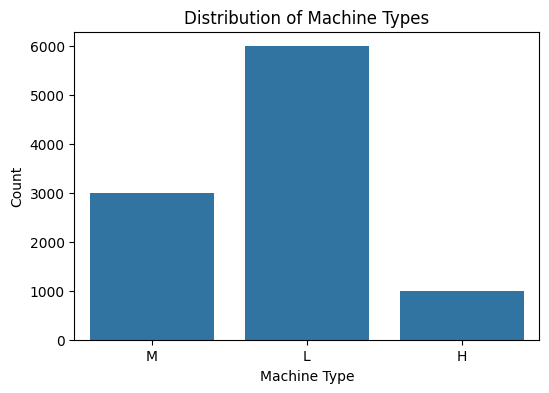

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df)
plt.title('Distribution of Machine Types')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.show()

# 2) 製品タイプ別の故障分布を可視化

#### 製品タイプごとの故障状況を確認し、特定のタイプで故障が多いかを分析する

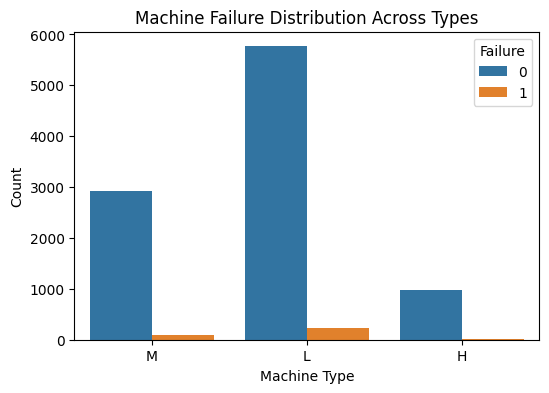

In [100]:
plt.figure(figsize=(6,4))
sns.countplot(x='Type', hue='Machine failure', data=df)
plt.title('Machine Failure Distribution Across Types')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.legend(title='Failure')
plt.show()

# 3) パターンや異常を確認するための特徴量分布の可視化

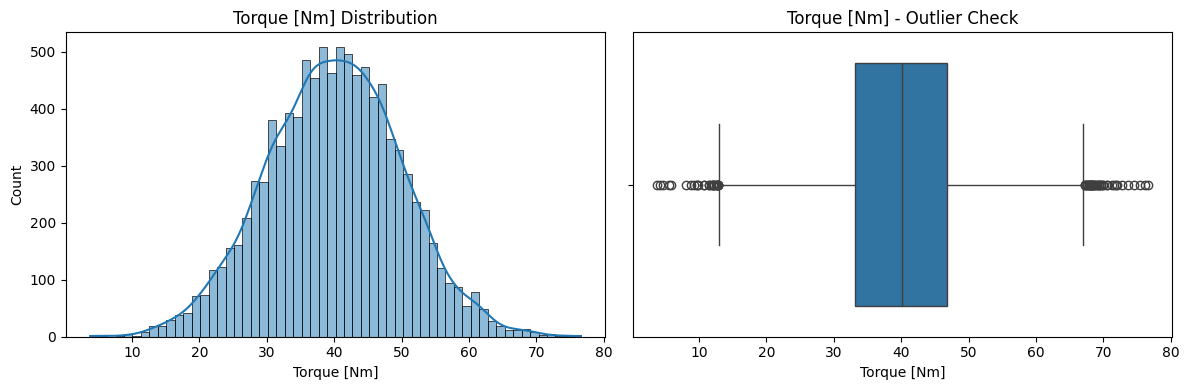

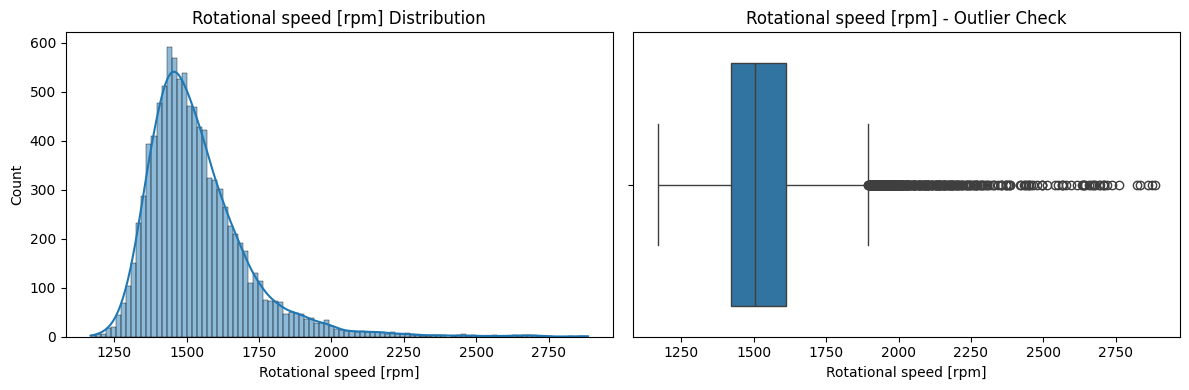

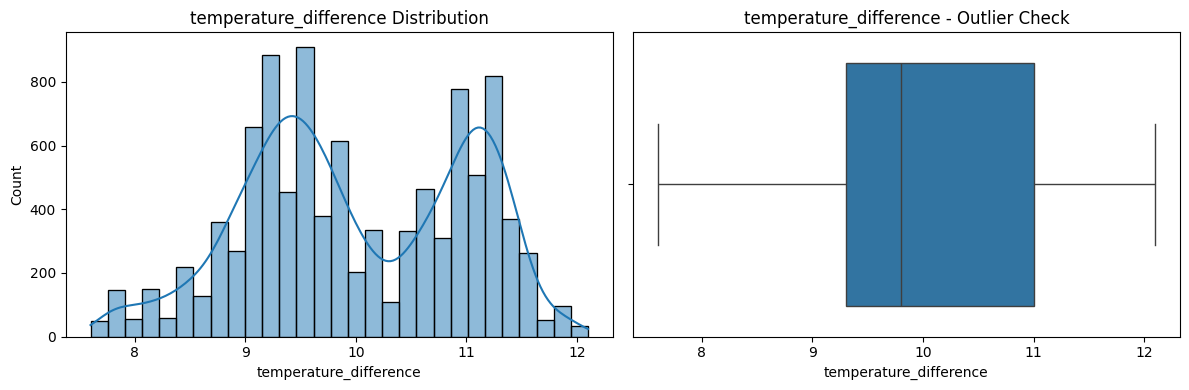

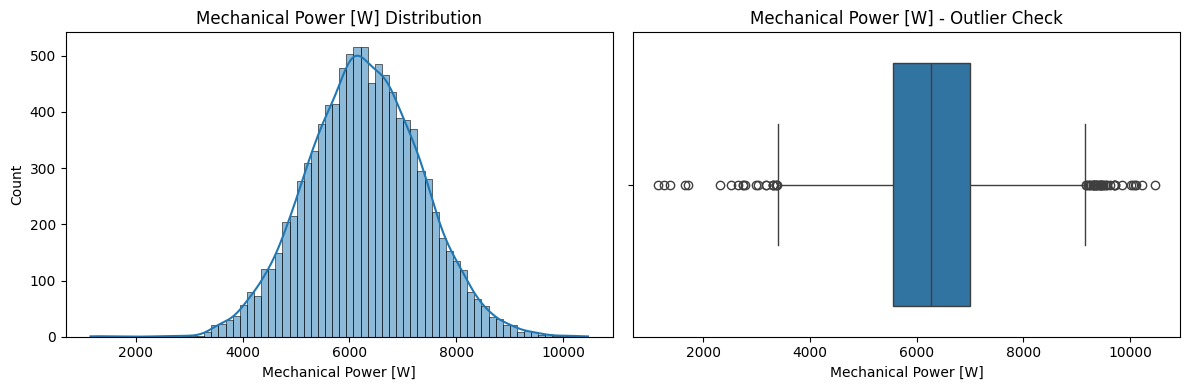

In [101]:
cols = ['Torque [Nm]', 'Rotational speed [rpm]', 'temperature_difference', 'Mechanical Power [W]']  # 可視化する特徴量を指定
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 各特徴量について、ヒストグラムと箱ひげ図を横並びで作成
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])  # ヒストグラムとKDEを用いてデータの分布を確認
    axes[0].set_title(f"{col} Distribution")
    sns.boxplot(data=df, x=col, ax=axes[1])  # 箱ひげ図を用いて外れ値の有無を確認
    axes[1].set_title(f"{col} - Outlier Check")
    plt.tight_layout()  # グラフ同士が重ならないようにレイアウトを調整
    plt.show()

トルク（Torque）は40 Nm前後を中心としたほぼ正規分布に近い形を示しており、低値側・高値側の両方に外れ値が確認できる。

回転速度（Rotational speed）は1500 rpm付近にデータが集中している一方、高回転側に長い裾を持つ右偏分布となっており、約1900 rpm以上に多数の外れ値が見られる。

温度差（temperature_difference）は9～10 K付近と11 K付近にピークがある二峰性の分布を示しており、箱ひげ図では顕著な外れ値は確認されない。

機械出力（Mechanical Power）は約6000～7000 Wを中心とした比較的対称な分布となっているが、低出力側および高出力側に外れ値が存在する。

全体として、各特徴量は異なる分布特性を持っており、特に回転速度と機械出力の外れ値については、故障との関係を今後確認する必要がある。

# 4) 特徴量間の関係を確認するペアプロット

#### 故障の有無で色分けし、各特徴量間の関係を可視化する

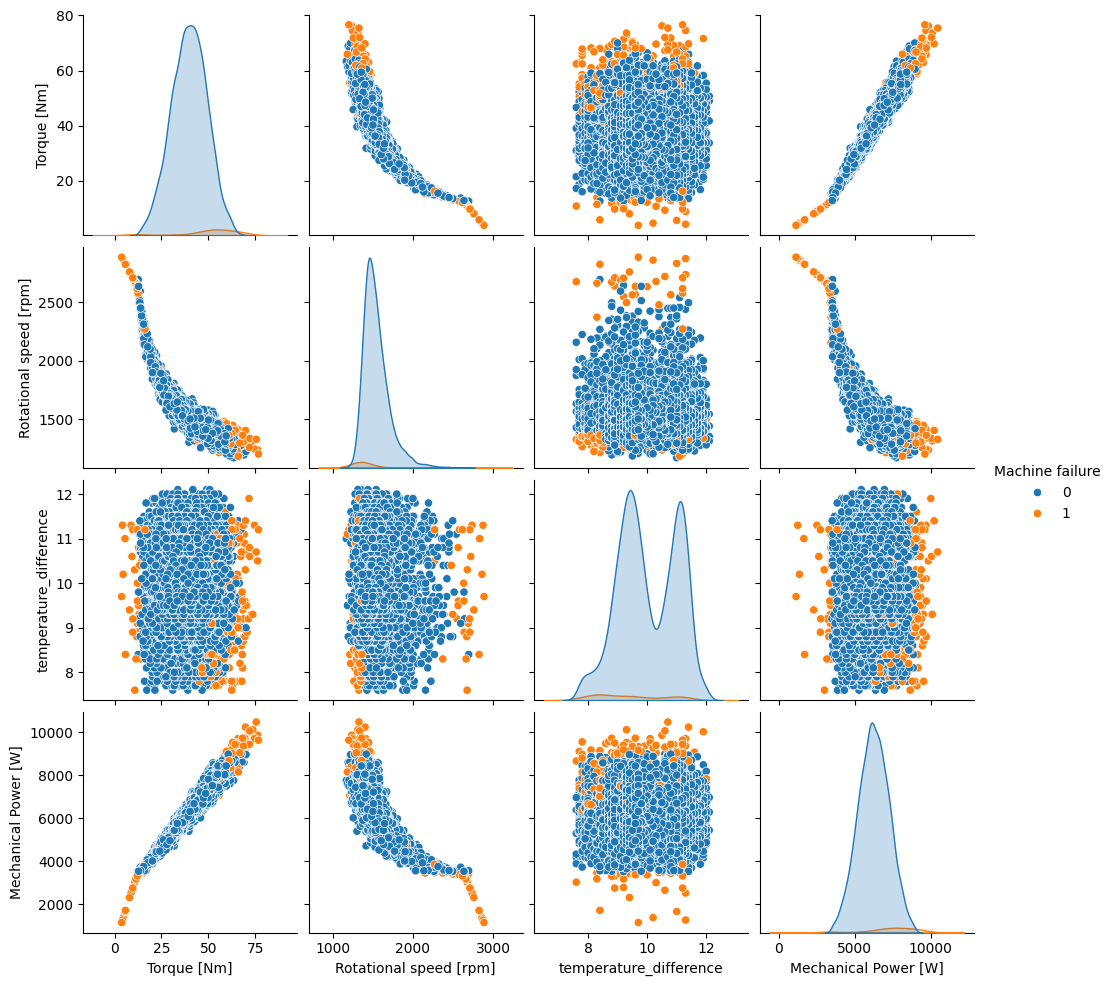

In [102]:
# 主要な特徴量と機械故障の関係をペアプロットで可視化
sns.pairplot(df[['Torque [Nm]', 'Rotational speed [rpm]', 'temperature_difference','Mechanical Power [W]', 'Machine failure']], hue='Machine failure')
plt.show()

ペアプロットを見ると、トルク（Torque）と回転速度（Rotational speed）の間には明確な負の関係があり、回転速度が高くなるほどトルクが低下する傾向が確認できる。また、トルクと機械出力（Mechanical Power）の間には強い正の関係が見られ、トルクの増加に伴って機械出力も増加している。一方、回転速度と機械出力の関係は非線形であり、特定の運転領域で出力が大きく変化している。温度差（temperature_difference）は他の特徴量との明確な相関があまり見られず、広い範囲に分布している。故障データ（Machine failure = 1）は、トルク・回転速度・機械出力の極端に高い領域や低い領域で比較的多く見られるため、通常の運転範囲から外れた状態が故障と関連している可能性がある。一方で、正常データと故障データには重なりも多く、単一の特徴量だけで故障を完全に判別することは難しいと考えられる。

### 特徴量間の相関

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

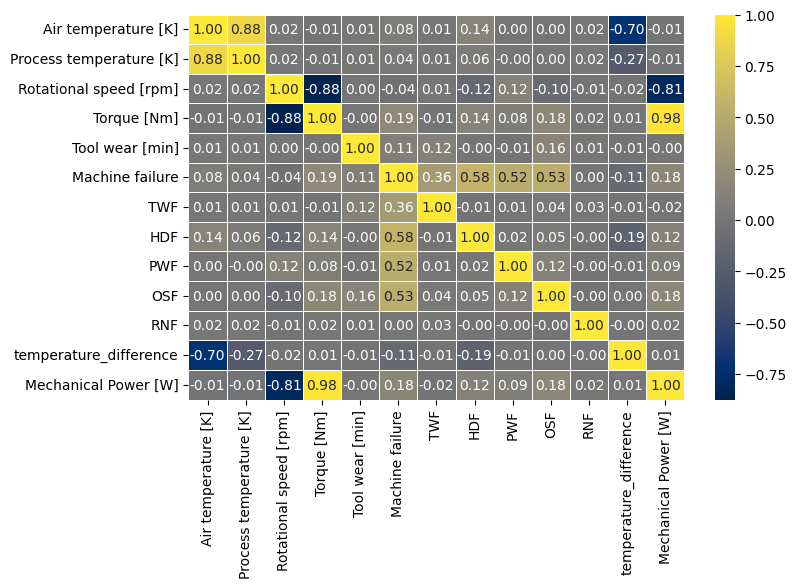

In [104]:
# ヒートマップを用いて数値特徴量間の相関を確認
corr_matrix=df.corr(numeric_only=True)  # 数値型の特徴量間の相関係数を計算
plt.figure(figsize=(8,5))  # ヒートマップのサイズを設定
sns.heatmap(corr_matrix,annot=True,cmap='cividis',fmt=".2f", linewidths=0.5)  # 相関係数をヒートマップで可視化

相関行列を見ると、空気温度とプロセス温度には強い正の相関（0.88）があり、回転速度とトルクには強い負の相関（-0.88）が確認できる。また、トルクと機械出力（Mechanical Power）は非常に強い正の相関（0.98）を示している。機械故障（Machine failure）は、HDF（0.58）、OSF（0.53）、PWF（0.52）と比較的強い相関があり、これらの故障要因との関係が大きいことが分かる。一方、RNFとの相関はほぼ見られない。

<Axes: >

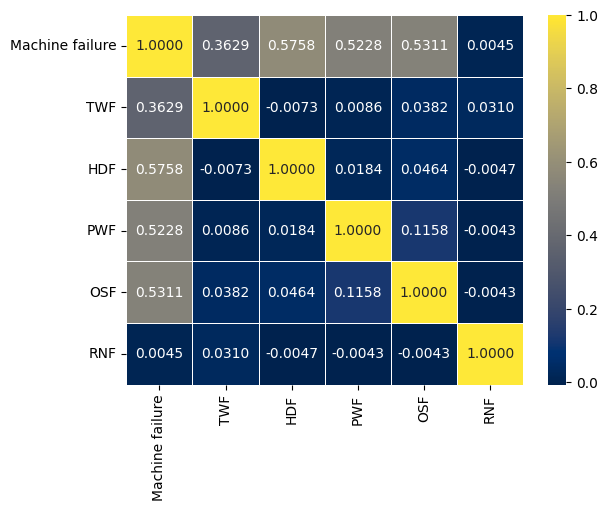

In [105]:
# ヒートマップを用いて各故障タイプ間の相関を確認
target=df.iloc[:,[6,7,8,9,10,11]]  # 故障関連の列を抽出
target_mat=target.corr()  # 各故障タイプ間の相関係数を計算
sns.heatmap(target_mat,annot=True,cmap="cividis",fmt=".4f",linewidth=0.5)  # 相関関係をヒートマップで可視化

工具摩耗故障（TWF）、放熱故障（HDF）、電力故障（PWF）、過負荷故障（OSF）、ランダム故障（RNF）は、目的変数である「Machine failure」と正の相関を示している。

TWF、HDF、PWF、OSF、RNF は具体的な故障タイプを示す変数であり、目的変数である「Machine failure」の結果情報を含んでいる。

そのまま説明変数として使用するとデータリークにつながる可能性があるため、これらの列を削除する。

In [106]:
df.drop(columns=['TWF','HDF','PWF','OSF','RNF'],inplace=True)  # 故障タイプに関する列を削除

In [107]:
df.sample(3)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,Mechanical Power [W]
7780,L,300.4,311.6,1815,23.5,49,0,11.2,4466.5594
4034,L,302.0,310.8,1615,29.0,235,1,8.8,4904.5497
9950,L,298.1,307.8,1413,54.1,113,0,9.7,8005.1237


### カテゴリ変数のエンコーディング

In [108]:
# カテゴリ変数（Type列）をラベルエンコーディング
from sklearn.preprocessing import LabelEncoder  # 機械学習モデルで扱えるように、カテゴリ変数「Type」をラベルエンコーディング
df['Type'] = LabelEncoder().fit_transform(df['Type'])  # Type列のカテゴリ値を数値に変換

### 特徴量スケーリング

In [109]:
# モデルで扱いやすいように、StandardScalerを用いて数値特徴量を標準化
from sklearn.preprocessing import StandardScaler  # StandardScalerを用いて数値特徴量を標準化
scale=StandardScaler()  # 標準化用のスケーラーを作成
data=pd.DataFrame(scale.fit_transform(df),columns=df.columns,index=df.index)  # 各特徴量を平均0・標準偏差1になるように変換

In [110]:
data.sample(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,Mechanical Power [W]
3946,1.333889,1.097448,0.872464,0.665033,-0.901537,-1.664562,-0.187322,-0.899691,-0.840724
7952,1.333889,0.447499,1.276869,-0.327854,0.091598,-1.256085,-0.187322,0.998328,0.055418
6345,-0.332223,0.097527,-0.138549,0.620409,-1.041980,-1.491745,-0.187322,-0.400212,-1.091691
1795,1.333889,-0.952389,-1.553968,-0.227450,-0.169225,-0.423419,-0.187322,-0.400212,-0.254474
2541,-1.998335,-0.452429,-0.812558,0.079341,-0.741030,-0.282022,-0.187322,-0.300317,-0.916288
106,-0.332223,-0.602417,-0.879959,-0.523085,0.854005,-0.596236,-0.187322,-0.100525,0.992423
7413,1.333889,0.047531,0.737662,0.430756,-0.480207,1.179071,-0.187322,0.998328,-0.302568
3994,-0.332223,1.147444,0.939865,-0.584443,0.031408,0.393537,-0.187322,-0.899691,-0.213581
9092,-0.332223,-1.352358,-1.284364,0.163011,-0.560460,1.351888,-0.187322,0.798537,-0.591405
7805,-0.332223,-0.052461,0.939865,0.932778,-1.122233,0.047902,-0.187322,1.497807,-1.062964


### 特徴量（X）と目的変数（y）にデータを分割

In [111]:
Y=df.pop("Machine failure")  # 目的変数「Machine failure」をYとして抽出
X=df  # 残りの列を特徴量Xとして設定

In [112]:
X

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_difference,Mechanical Power [W]
0,2,298.1,308.6,1551,42.8,0,10.5,6951.5906
1,1,298.2,308.7,1408,46.3,3,10.5,6826.7227
2,1,298.1,308.5,1498,49.4,5,10.4,7749.3875
3,1,298.2,308.6,1433,39.5,7,10.4,5927.5047
4,1,298.2,308.7,1408,40.0,9,10.5,5897.8166
...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604,29.5,14,9.6,4955.1294
9996,0,298.9,308.4,1632,31.8,17,9.5,5434.7040
9997,2,299.0,308.6,1645,33.4,22,9.6,5753.6175
9998,0,299.0,308.7,1408,48.5,25,9.7,7151.1026


In [113]:
Y

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Machine failure, Length: 10000, dtype: int64

### 不均衡データへの対応

In [114]:
# SMOTE（Synthetic Minority Over-sampling Technique：少数クラスの合成オーバーサンプリング手法）
# SMOTEは、機械学習における不均衡データを処理するための手法である。
# 目的：合成サンプルを作成することで、少数クラスのデータ数を増やす。
# 仕組み：既存の少数クラスのデータと、その近傍データとの間を補間して新しいサンプルを生成する。
# これにより、モデルが少数クラスの特徴をより学習しやすくなり、不均衡データに対する予測性能の向上が期待できる。

In [115]:
# SMOTE適用前のクラス分布を表示
from collections import Counter
counts = Counter(Y)  # 目的変数Yの各クラスの件数を集計
print(counts)  # クラスごとの件数を表示

Counter({0: 9661, 1: 339})


In [116]:
# SMOTEを用いて少数クラスのサンプルを増やす
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)  # 再現性を確保するため random_state を指定
X_resampled, y_resampled = smote.fit_resample(X, Y)  # 特徴量Xと目的変数YにSMOTEを適用して再サンプリング

In [117]:
# SMOTE適用後のクラス分布を表示
from collections import Counter
counts = Counter(y_resampled )  # 再サンプリング後の目的変数について、各クラスの件数を集計
print(counts)  # クラスごとの件数を表示

Counter({0: 9661, 1: 9661})


### 学習データとテストデータへの分割

In [118]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X_resampled,y_resampled,test_size=0.1)

### どのアルゴリズムが最も高い精度を示すか確認する

In [119]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV,SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier,BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [120]:
# 比較する分類モデルを定義
models = {
    'Logistic Regression': LogisticRegression(),
        'Logistic Regression CV': LogisticRegressionCV(),
    'SGD': SGDClassifier(),
    
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Bagging': BaggingClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

In [121]:
# データセット上で各モデルを学習し、最も高いAccuracyを示すモデルを確認する関数を作成
def evaluate_model(X_train,X_test,Y_train,Y_test):
    result=[]
    for name, model in models.items():  # 各モデルについて学習と予測を実行
        model.fit(X_train,Y_train)
        y_pred=model.predict(X_test)
        acc=accuracy_score(Y_test,y_pred)  # Accuracyを計算して結果を保存
        result.append((name,acc))
    result.sort(key=lambda x: x[1], reverse=True)  # Accuracyの高い順に並べ替え
    return result

In [122]:
results = evaluate_model(X_train,X_test,Y_train,Y_test)  # 各モデルの評価結果を取得
print("Model Performance:")  # モデルごとのAccuracyを表示
for name, acc in results:
    print(f"{name}: {acc:.6f}")

Model Performance:
Random Forest: 0.983963
Bagging: 0.978272
Decision Tree: 0.975685
Gradient Boosting: 0.958614
K-Nearest Neighbors: 0.932747
AdaBoost: 0.925504
Logistic Regression: 0.873254
Logistic Regression CV: 0.873254
Support Vector Machine: 0.798758
SGD: 0.627522


ここでは、Random Forest がすべてのアルゴリズムの中で最も高いAccuracyを示していることが分かる。

そのため、さらにパラメータを調整し、より高い性能を目指す。

In [123]:
RF=RandomForestClassifier(class_weight='balanced')  # クラス不均衡を考慮したRandom Forestモデルを作成

In [124]:
RF.fit(X_train,Y_train)  # 学習データを用いてRandom Forestモデルを学習
y_pred=RF.predict(X_test)  # テストデータに対して予測を実行
acc=accuracy_score(Y_test,y_pred)  # Accuracyを計算してモデル性能を評価

In [125]:
acc  # Accuracyを表示

0.9865494050698397

In [126]:
# Accuracy、Precision、Recall、F1-scoreを用いてモデルの性能を確認

In [127]:
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    roc_auc_score, 
    RocCurveDisplay, 
    precision_recall_curve, 
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
# Accuracy、Precision、Recall、F1-scoreなどを用いてモデル性能を評価する関数を定義
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)  # テストデータに対してクラスを予測
    y_prob = model.predict_proba(X_test)[:, 1]  # クラス1（故障）の予測確率を取得

    # Precision、Recall、F1-scoreなどの分類評価指標を表示
    print(f"--------- {model_name} Classification Report ------ \n\n")
    print(classification_report(y_test, y_pred))

    # 混同行列を作成し、予測結果を可視化
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC-AUCを計算し、ROC曲線を表示
    roc_auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{model_name} - ROC Curve (AUC = {roc_auc:.2f})")
    plt.show()

    # Precision-Recall曲線を作成して表示
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    PrecisionRecallDisplay(precision=precision, recall=recall).plot()
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.show()

--------- Random Forest Classification Report ------ 


              precision    recall  f1-score   support

           0       0.99      0.98      0.99       986
           1       0.98      0.99      0.99       947

    accuracy                           0.99      1933
   macro avg       0.99      0.99      0.99      1933
weighted avg       0.99      0.99      0.99      1933



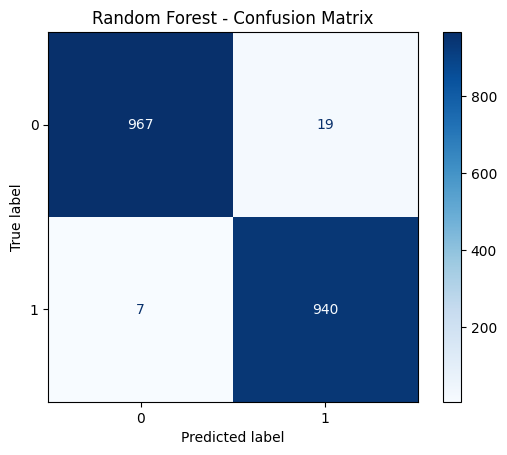

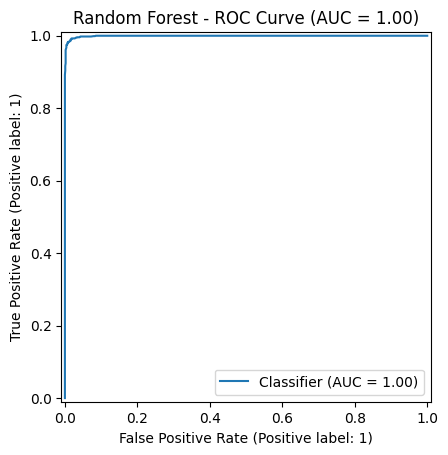

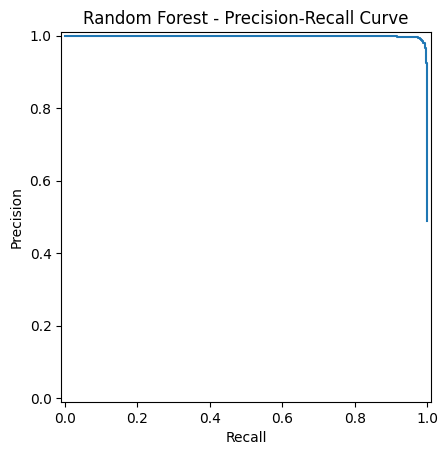

In [129]:
evaluate_model(RF, X_test, Y_test, model_name="Random Forest")  # Random Forestモデルの性能を総合的に評価

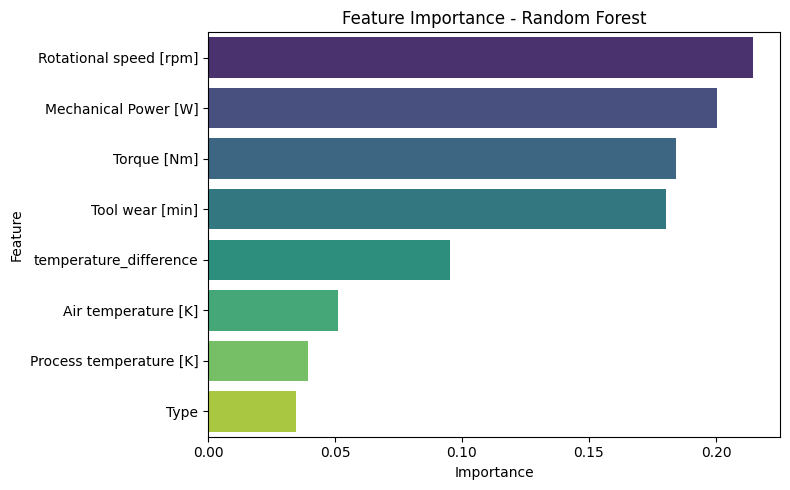

In [130]:
importances = RF.feature_importances_  # Random Forestモデルから各特徴量の重要度を取得
feature_names = X.columns  # 特徴量名を取得

# 特徴量名と重要度をDataFrameにまとめ、重要度の高い順に並べ替え
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 特徴量の重要度を棒グラフで可視化
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance - Random Forest')  # グラフのタイトルを設定
plt.tight_layout()
plt.show()